# Generic FWER calibration for skchange detectors

skchange detectors fire when a penalised interval score exceeds zero. Their
default (BIC-style) penalties depend only on `(n_samples, n_features)`, so on
short series they can raise **far more false alarms than intended**.

This notebook shows how to calibrate a detector's `penalty_scale` so the
**family-wise error rate** (FWER) — the probability of flagging *at least one*
change on change-free data — matches a target `level`.

**Idea (one line).** For each change-free ("null") sample, find the smallest
`penalty_scale` that suppresses every detection; the calibrated scale is the
`(1 - level)` quantile of those critical scales. It uses only the public detector
API via `skchange.new_api.tuning.unpenalised_scores` / `predict_scores`.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skchange.new_api.detectors import (
    SeededBinarySegmentation,
    MovingWindow,
    CircularBinarySegmentation,
)
from skchange.new_api.tuning import (
    calibrate_penalty_scale,
    CalibratedDetector,
    PermutationSampler,
    GaussianMCSampler,
)

N, P = 150, 2  # short series -> default penalties are miscalibrated
LEVEL = 0.05  # target FWER
N_SIMS = 999  # Monte Carlo draws for calibration
N_EVAL = 2000  # independent null series to estimate empirical FWER


def empirical_fwer(detector, n_eval=N_EVAL, n=N, p=P, seed=99):
    """Fraction of change-free series on which the detector flags >=1 change."""
    rng = np.random.default_rng(seed)
    fa = 0
    for _ in range(n_eval):
        X = rng.normal(size=(n, p))
        detector.fit(X)
        if len(detector.predict_changepoints(X)) > 0:
            fa += 1
    return fa / n_eval


def detection_power(detector, n_eval=1000, n=N, p=P, shift=0.5, seed=123):
    """Fraction of series with a real mean shift that the detector flags.

    A modest shift (0.5) is used so that over-conservative penalties visibly
    lose power rather than detecting every change regardless.
    """
    rng = np.random.default_rng(seed)
    hits = 0
    for _ in range(n_eval):
        X = np.vstack(
            [rng.normal(0, 1, (n // 2, p)), rng.normal(shift, 1, (n - n // 2, p))]
        )
        detector.fit(X)
        if len(detector.predict_changepoints(X)) > 0:
            hits += 1
    return hits / n_eval


def null_data(n=N, p=P, seed=0):
    return np.random.default_rng(seed).normal(size=(n, p))

## 1. The problem: default penalties over-fire on short series

We measure the empirical FWER of the default `SeededBinarySegmentation` on
change-free `N(0, 1)` data. The nominal target is 5%.

In [2]:
default_detector = SeededBinarySegmentation()
fwer_default = empirical_fwer(default_detector)
print(f"Default penalty_scale = {default_detector.penalty_scale}")
print(f"Empirical FWER (default) = {fwer_default:.1%}   (target {LEVEL:.0%})")

Default penalty_scale = 1.0
Empirical FWER (default) = 92.7%   (target 5%)


## 2. One-liner calibration with `CalibratedDetector`

`CalibratedDetector` wraps any supported detector, calibrates `penalty_scale` in
`fit`, and delegates prediction to the calibrated detector.

In [3]:
X = null_data()
cal = CalibratedDetector(
    SeededBinarySegmentation(), level=LEVEL, n_simulations=N_SIMS, random_state=1
).fit(X)

print(f"Calibrated penalty_scale_ = {cal.penalty_scale_:.3f}")
fwer_cal = empirical_fwer(cal.detector_)
print(f"Empirical FWER (calibrated) = {fwer_cal:.1%}   (target {LEVEL:.0%})")

Calibrated penalty_scale_ = 1.493
Empirical FWER (calibrated) = 4.8%   (target 5%)


## 3. The engine function (power-user path)

`calibrate_penalty_scale` returns just the scale, for use in custom loops. It
matches what the meta-estimator computes.

In [4]:
scale = calibrate_penalty_scale(
    SeededBinarySegmentation(),
    X,
    level=LEVEL,
    n_simulations=N_SIMS,
    random_state=1,
)
print(f"calibrate_penalty_scale -> {scale:.3f}")
assert np.isclose(scale, cal.penalty_scale_)
print("matches CalibratedDetector.penalty_scale_  ✓")

calibrate_penalty_scale -> 1.493
matches CalibratedDetector.penalty_scale_  ✓


## 4. Across detectors

All three single-penalty detectors are calibrated the same way. We compare
empirical FWER before and after calibration.

In [5]:
detectors = {
    "SeededBinSeg": SeededBinarySegmentation(),
    "MovingWindow": MovingWindow(),
    "CircularBinSeg": CircularBinarySegmentation(),
}

rows = []
for name, det in detectors.items():
    c = calibrate_penalty_scale(
        det, X, level=LEVEL, n_simulations=N_SIMS, random_state=1
    )
    f_def = empirical_fwer(det)
    f_cal = empirical_fwer(det.__class__().set_params(penalty_scale=c))
    rows.append((name, det.penalty_scale, c, f_def, f_cal))

print(
    f"{'detector':16s}{'default_scale':>14s}{'cal_scale':>11s}"
    f"{'FWER_def':>10s}{'FWER_cal':>10s}"
)
for name, ds, c, fd, fc in rows:
    print(f"{name:16s}{ds:>14.2f}{c:>11.2f}{fd:>10.1%}{fc:>10.1%}")

detector         default_scale  cal_scale  FWER_def  FWER_cal
SeededBinSeg              1.00       1.49     92.7%      4.8%
MovingWindow              1.00       1.48     91.6%      3.7%
CircularBinSeg            2.00       1.44      0.1%      5.0%


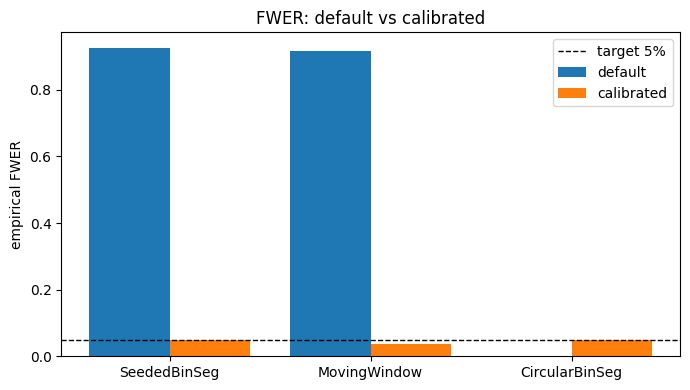

In [6]:
names = [r[0] for r in rows]
fwer_def = [r[3] for r in rows]
fwer_cal = [r[4] for r in rows]
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.2, fwer_def, 0.4, label="default")
ax.bar(x + 0.2, fwer_cal, 0.4, label="calibrated")
ax.axhline(LEVEL, color="k", ls="--", lw=1, label=f"target {LEVEL:.0%}")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("empirical FWER")
ax.legend()
ax.set_title("FWER: default vs calibrated")
plt.tight_layout()
plt.show()

## 5. Samplers and clean vs contaminated null data

The **null model** decides what "change-free" data looks like. Two things matter:

**(a) The sampler's distributional assumptions.**

- `"permutation"` (default) — resamples rows of the supplied data; makes *no*
  distributional assumption.
- `"gaussian"` — draws i.i.d. `N(0, 1)`; tightest *when the null really is Gaussian*.
- any callable `f(n_samples, n_features, rng) -> array` for a custom null.

> ⚠️ **Caveat.** The calibrated scale is an upper quantile of a *maximum*
> statistic, which lives in the extreme tail. A permutation null can only
> reshuffle the values it has seen — it cannot generate fresh extremes — so it is
> higher-variance and can be mildly **anti-conservative** (over-firing). When the
> null family is known, a parametric sampler is tighter. Either way, more
> `n_simulations` reduces the variance. We see this below: `gaussian` lands near
> the 5% target, while `permutation` overshoots somewhat.

**(b) Whether the calibration data is itself change-free.**

If you calibrate on data that **contains a real change**, the null samples
inherit inflated scores → the penalty is pushed up → calibration becomes
**over-conservative** and you lose detection power. Passing clean change-free
data via `X_calib` fixes this. The table below reports both FWER (on null data)
and power (on data with a genuine shift) to make the trade-off visible.

In [7]:
rng = np.random.default_rng(7)
# Calibration data that CONTAINS a real change (mean shift at t=75):
X_changed = np.vstack([rng.normal(0, 1, (75, P)), rng.normal(2, 1, (75, P))])
# A separate, clean change-free calibration set:
X_clean = rng.normal(0, 1, (400, P))

strategies = {
    "permutation (contaminated X)": dict(X=X_changed, sampler="permutation"),
    "permutation (clean X_calib)": dict(
        X=X_changed, X_calib=X_clean, sampler="permutation"
    ),
    "gaussian N(0,1)": dict(X=X_changed, sampler="gaussian"),
}

print(f"{'strategy':32s}{'cal_scale':>11s}{'FWER':>9s}{'power':>9s}")
for name, kw in strategies.items():
    c = calibrate_penalty_scale(
        SeededBinarySegmentation(),
        level=LEVEL,
        n_simulations=N_SIMS,
        random_state=1,
        **kw,
    )
    det = SeededBinarySegmentation().set_params(penalty_scale=c)
    f = empirical_fwer(det)
    pw = detection_power(det)
    print(f"{name:32s}{c:>11.2f}{f:>9.1%}{pw:>9.1%}")

strategy                          cal_scale     FWER    power
permutation (contaminated X)           2.33     0.0%     3.4%
permutation (clean X_calib)            1.38    12.0%    81.5%
gaussian N(0,1)                        1.46     6.0%    74.5%


## 6. Level sweep (calibration curve)

Empirical FWER should track the nominal level across a range of targets.

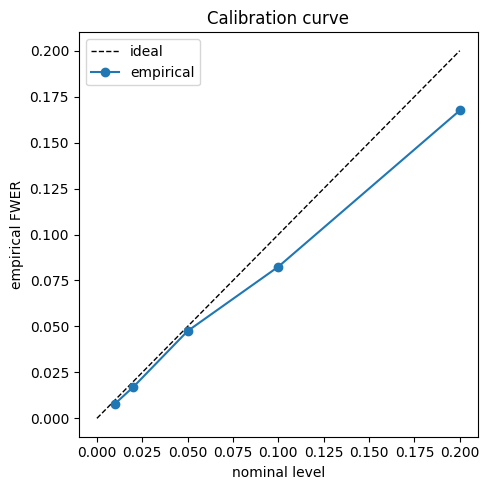

{0.01: 0.008, 0.02: 0.017, 0.05: 0.048, 0.1: 0.083, 0.2: 0.168}


In [8]:
levels = [0.01, 0.02, 0.05, 0.10, 0.20]
emp = []
for lv in levels:
    c = calibrate_penalty_scale(
        SeededBinarySegmentation(),
        X,
        level=lv,
        n_simulations=999,
        random_state=1,
    )
    emp.append(empirical_fwer(SeededBinarySegmentation().set_params(penalty_scale=c)))

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 0.2], [0, 0.2], "k--", lw=1, label="ideal")
ax.plot(levels, emp, "o-", label="empirical")
ax.set_xlabel("nominal level")
ax.set_ylabel("empirical FWER")
ax.set_title("Calibration curve")
ax.legend()
plt.tight_layout()
plt.show()
print(dict(zip(levels, [round(e, 3) for e in emp])))

## 7. Power sanity-check

Calibration must control false alarms **without** silencing real changes. We
insert a genuine mean shift and confirm the calibrated detector still detects it.

In [9]:
rng = np.random.default_rng(3)
X_signal = np.vstack([rng.normal(0, 1, (75, P)), rng.normal(3, 1, (75, P))])
cal = CalibratedDetector(
    SeededBinarySegmentation(), level=LEVEL, n_simulations=N_SIMS, random_state=1
).fit(null_data())  # calibrate on change-free data
cps = cal.predict_changepoints(X_signal)
print(f"calibrated penalty_scale_ = {cal.penalty_scale_:.3f}")
print(f"detected changepoints near t=75: {cps}")

calibrated penalty_scale_ = 1.493
detected changepoints near t=75: [75]


## 8. Scratch

Use the cell(s) below to experiment — try other detectors, samplers, `level`s,
series lengths, or your own `null_sampler` callable.

In [10]:
# your experiments here